# Detached-sonde terminal velocity — `V_T(ρ)` for every sample

Companion to `wbuoy_drag_short.ipynb`, which handles the **balloon-attached** case. This is
the **detached** case: the hailsonde falling under its own weight once the balloon is gone.

The sonde is a rigid sphere, so its terminal velocity follows from weight balancing drag:

$$V_T(\rho) = \sqrt{\frac{2\,m\,g}{\rho\,C_D\,A}}, \qquad A = \frac{\pi D^2}{4}$$

with mass `m` and diameter `D` per hardware version (v1: 25 g, 65 mm; v2: 20 g, 50 mm), a
fixed smooth-sphere `C_D = 0.47`, and `ρ` the ambient density at each sample. Nothing is
fitted: the density dependence, `V_T ∝ ρ^-0.5`, is part of the formula.

**Why not the observed descent rate.** An earlier version of this notebook calibrated `V_T`
from the near-ground descent. That value is biased high: every sonde in this dataset fell
through a downdraft, and some carried ice, adding mass. Both make a sonde fall faster than a
clean sphere in still air. §2 keeps the observed value as a comparison; the gap between the
two is a rough measure of downdraft plus ice.

**Caveat.** `V_T` here is for a clean sonde. Where a sonde has accumulated ice its true `V_T`
is higher, so `w_air` derived from this `V_T` overstates the downdraft there.

The full treatment of the observed near-ground descent — the shedding diagnostic, the
settling check and the figures — is in `vt_detached.ipynb`.

**Input:** `v2026/<yyyymmdd>/<category>/<stem>.alt.csv`. Standalone.

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================== PARAMETERS ==================================
V2_ID_MIN, V2_ID_MAX = 15312, 15399        # v1: id < V2_ID_MIN;  v2: V2_ID_MIN..V2_ID_MAX

# sonde as an idealised rigid sphere, per hardware version
PAYLOAD  = {"v1": 0.025, "v2": 0.020}      # kg, sonde mass (clean, no ice)
DIAMETER = {"v1": 0.065, "v2": 0.050}      # m, sphere diameter

# C_D of a smooth sphere is close to constant at ~0.47 across the subcritical range,
# Re ~ 1e3 to 2e5, ending at the drag crisis near Re ~ 3e5.  Here Re = rho V D / mu
# ~ 3e4 to 8e4 for both sondes (rho 0.2-1.05 kg/m3, V ~ 17-46 m/s, D = 50-65 mm,
# mu ~ 1.6-1.8e-5 Pa s), well inside that range, so a fixed value is justified.
CD_SPHERE = 0.47       # dimensionless, drag coefficient of a smooth sphere

EXPONENT  = 0.4        # V_T ~ rho^-EXPONENT, only to normalise the observed descent in §2
                       # (fitted in vt_detached.ipynb; sphere theory gives 0.5)

MIN_FILE_N   = 20      # samples a file must keep after cleaning to be loaded at all
NG_BAND      = 1000.0  # m AGL, band the near-ground fall speed is measured over
FALL_MIN     = 15.0    # m/s, below this something is still supporting the sonde
MIN_NG_N     = 10      # samples a case must contribute to the near-ground band

DATA = Path("/home/meso/data/icechip-hailsonde-data/v2026")    # campaign root: <yyyymmdd>/<category>/<stem>.alt.csv
# ============================================================================

R_DRY = 287.05    # J kg-1 K-1, gas constant for dry air
G     = 9.81      # m s-2, gravitational acceleration


def sphere_vt(rho, mass, diameter, cd=CD_SPHERE):
    """
    Terminal velocity of a rigid sphere falling in still air, where weight balances drag.

      V_T = sqrt(2 m g / (rho * C_D * A)),   A = pi D^2 / 4

    Parameters
    ----------
    rho : float or array_like
        Air density (kg m-3).
    mass : float or array_like
        Sphere mass (kg).
    diameter : float or array_like
        Sphere diameter (m).
    cd : float
        Drag coefficient (dimensionless).

    Returns
    -------
    vt : float or array_like
        Terminal velocity (m/s), positive downward, same shape as the inputs.
    """
    area   = np.pi * diameter ** 2 / 4.0    # m2, frontal area
    weight = mass * G                       # N
    return np.sqrt(2.0 * weight / (rho * cd * area))


# echo the formula
print("V_T(rho) = sqrt(2 m g / (rho * C_D * pi D^2 / 4)),  C_D =", CD_SPHERE)

V_T(rho) = sqrt(2 m g / (rho * C_D * pi D^2 / 4)),  C_D = 0.47


## 1. Load

One row per transmitted sample. Fall speed `w` is the negated rise speed, positive
downward. The vendor's `Density` column is only about 55 % populated, so it falls back to
`p / (R_d T)`.

Height above ground uses the vendor's own AGL field rather than a launch altitude derived
from the first samples: several files begin with the sonde already aloft, which would put
the near-ground band kilometres above the ground.

In [3]:
def _num(column):
    """Parse a text column to float; blank or unparseable entries become NaN."""
    stripped = column.astype(str).str.strip()
    blanked  = stripped.replace("", np.nan)
    return pd.to_numeric(blanked, errors="coerce")


def sonde_id(stem):
    """Sonde serial number: the third underscore-separated field of the file stem."""
    return int(stem.split("_")[2])


def sonde_version(stem):
    """Hardware version from the serial range: "v1", "v2", or None if outside both."""
    sid = sonde_id(stem)
    if sid < V2_ID_MIN:
        return "v1"
    return "v2" if sid <= V2_ID_MAX else None


def load(root=DATA):
    """Read every .alt.csv under `root` into one DataFrame, one row per sample."""
    # list (dim: sounding) of DataFrame, one per file kept
    frames = []
    for csv_path in sorted(root.rglob("*.alt.csv")):
        # read the file; the column header is on its third line
        stem = csv_path.name[: -len(".alt.csv")]
        raw = pd.read_csv(csv_path, skiprows=2, skipinitialspace=True)
        raw.columns = [c.strip() for c in raw.columns]

        # keep the columns used downstream, under short names, as floats
        sounding = pd.DataFrame({
            "case":     stem,
            "sonde_id": sonde_id(stem),
            "version":  sonde_version(stem),
            "category": csv_path.parent.name,
            "t":        _num(raw["Time from launch (sec)"]),   # s
            "alt":      _num(raw["Altitude (m MSL)"]),         # m MSL
            "agl":      _num(raw["Height (m AGL)"]),           # m AGL
            "rise":     _num(raw["Rise speed (m/s)"]),         # m/s, barometric, positive up
            "rise_gps": _num(raw["GPS rise speed (m/s)"]),     # m/s, GPS, positive up
            "temp":     _num(raw["Temperature (C)"]),          # deg C
            "p":        _num(raw["Pressure (Pa)"]),            # Pa
        })

        # drop rows without time or altitude, drop repeated timestamps, put in time order
        sounding = sounding.dropna(subset=["t", "alt"])
        sounding = sounding.drop_duplicates("t")
        sounding = sounding.sort_values("t")

        # skip files left with too few samples to use
        if len(sounding) >= MIN_FILE_N:
            frames.append(sounding.reset_index(drop=True))

    return pd.concat(frames, ignore_index=True)


# load all soundings into one table, one row per sample
samples = load()

# density (kg/m3)
rho_ideal        = samples["p"] / (R_DRY * (samples["temp"] + 273.15))
samples["rho_ideal"] = rho_ideal

# fall speeds (m/s), positive downward: barometric and GPS
samples["w"]     = -samples["rise"]
samples["w_gps"] = -samples["rise_gps"]

# summarise what was loaded
print(f"{samples.case.nunique()} soundings, {len(samples):,} samples")
print(samples.groupby("version").case.nunique().rename("soundings").to_string())

61 soundings, 87,608 samples
version
v1    25
v2    36


## 2. Observed near-ground descent, compared with the idealised `V_T`

The idealised `V_T` needs nothing from the data. This section measures how fast the sondes
actually fell near the ground, as a check on it.

`V_T,obs` is the median fall speed over the lowest `NG_BAND` metres of the descent, normalised
per case to a common reference density `ρ_ref` and then pooled per version. Each case is
normalised with the density *where its fall speed was measured* — the median over those same
descent samples — rather than the launch density: the band's samples sit around 750 m AGL,
where the air is 4–7 % thinner than at launch even inside the cold downdraft. The median is
used rather than the mean because the spread between flights is heavy-tailed.

`V_T,obs` is **not** a terminal velocity. Every sonde fell through a downdraft and some
carried ice; both push it above the idealised value, so `V_T,obs − V_T` is a rough measure
of downdraft plus ice loading near the ground.

The near-ground band needs no free-fall segment detection: by the time the sonde is within
a kilometre of the ground the remnant has finished shedding, which is what
`vt_detached.ipynb` §5 establishes. Three records never settle, and are excluded explicitly
rather than by a detector, so the exclusion is auditable. Note that sample count is *not* a
usable filter here — a fast-falling sonde spends less time in the band and so contributes
*fewer* samples, so raising `MIN_NG_N` preferentially discards the best cases.

In [4]:
# Records that never settle into terminal fall, or are too short to tell.
# Checked against GPS: the first disagrees with the GPS solution by 8 m/s.
SKIP = {
    "2025-06-05_1802_15352",   # 42 descent samples; baro 9.2 vs GPS 17.6 m/s
    "2025-05-19_1957_15349",   # telemetry ends 432 m MSL; 15 s of fall, still accelerating
    "2025-06-22_1928_9501",    # w grows 5 -> 19 m/s through the band; remnant still shedding
}

# Which rows are on the descent?  `transform("idxmax")` tags every row with the
# index label of the highest sample *of its own case*.  `samples` carries one plain
# 0..N-1 index across all cases, and each case's rows are contiguous and in time
# order, so a row whose own label exceeds its case's apex label sits after the
# apex -- i.e. the sonde is on its way down.
apex = samples.groupby("case").alt.transform("idxmax")

# Settled free fall: past the apex, inside the band, and actually falling.
descending = samples.index > apex
in_band    = samples.agl < NG_BAND
falling    = samples.w > FALL_MIN
usable     = samples.rho_ideal.notna() & samples.version.notna() & ~samples.case.isin(SKIP)
# collate samples
ng = samples[descending & in_band & falling & usable]

# Collapse to one row per case: its fall speed and the density it was measured at
per_case = ng.groupby("case").agg(
    version=("version", "first"),      # constant within a case, so "first" just carries it
    w_obs=("w", "median"),             # m/s, this case's near-ground fall speed
    rho_obs=("rho_ideal", "median"),   # kg/m3, density over the same descent samples
    n=("w", "size"),                   # samples it contributed to the band
)
per_case = per_case[per_case.n >= MIN_NG_N]

# reference density (kg/m3) every case is normalised to: the campaign median of rho_obs
RHO_REF = float(per_case.rho_obs.median())

# near-ground fall speed (m/s) each case would have at RHO_REF
per_case["vt_ref"] = per_case.w_obs * (per_case.rho_obs / RHO_REF) ** EXPONENT

# pooled observed V_T,obs (m/s) at RHO_REF, a Series indexed by version
VT_REF = per_case.groupby("version").vt_ref.median()

def _fmt_2dp(value):
    """Fixed-width, two-decimal number format for the printed tables."""
    return f"{value:8.2f}"


# summarise V_T,obs per version
print(f"rho_ref = {RHO_REF:.3f} kg/m3 (campaign median of descent-band density); "
      f"{len(per_case)} of {samples.case.nunique()} cases reach the band and settle\n")
version_stats = per_case.groupby("version").vt_ref.agg(
    n="size",
    vt_obs="median",
    sd="std",
    lo="min",
    hi="max",
)
print(version_stats.to_string(float_format=_fmt_2dp))

# flight-to-flight spread of V_T,obs, in m/s and as a percentage of the pooled value
print("\nspread between flights reflects downdraft, ice and remnant, not measurement:")
for version in VT_REF.index:
    vt_ref_flights = per_case.loc[per_case.version == version, "vt_ref"]
    spread     = vt_ref_flights.std()                       # m/s
    spread_pct = 100.0 * spread / VT_REF[version]           # %
    print(f"  {version}: V_T,obs = {VT_REF[version]:.2f} m/s, "
          f"individual flights +/-{spread:.1f} ({spread_pct:.0f}%)")

rho_ref = 0.980 kg/m3 (campaign median of descent-band density); 16 of 61 cases reach the band and settle

          n   vt_obs       sd       lo       hi
version                                        
v1        6    21.90     3.32    18.55    28.12
v2       10    22.97     5.02    16.50    32.65

spread between flights reflects downdraft, ice and remnant, not measurement:
  v1: V_T,obs = 21.90 m/s, individual flights +/-3.3 (15%)
  v2: V_T,obs = 22.97 m/s, individual flights +/-5.0 (22%)


In [5]:
# idealised V_T at the same reference density, against the observed near-ground value;
# the gap is a rough measure of downdraft plus ice loading
print(f"at rho_ref = {RHO_REF:.3f} kg/m3, C_D = {CD_SPHERE}\n")
for version in VT_REF.index:
    vt_ideal = sphere_vt(RHO_REF, PAYLOAD[version], DIAMETER[version])    # m/s
    vt_gap   = VT_REF[version] - vt_ideal                                  # m/s, observed minus idealised
    print(f"  {version}: D = {1000.0 * DIAMETER[version]:.0f} mm, m = {1000.0 * PAYLOAD[version]:.0f} g"
          f"  ->  V_T ideal {vt_ideal:.2f} m/s, V_T,obs {VT_REF[version]:.2f} m/s, "
          f"gap {vt_gap:+.2f} m/s")

at rho_ref = 0.980 kg/m3, C_D = 0.47

  v1: D = 65 mm, m = 25 g  ->  V_T ideal 17.92 m/s, V_T,obs 21.90 m/s, gap +3.98 m/s
  v2: D = 50 mm, m = 20 g  ->  V_T ideal 20.83 m/s, V_T,obs 22.97 m/s, gap +2.14 m/s


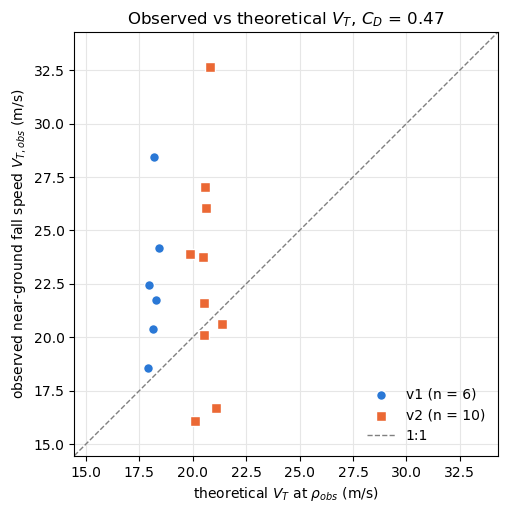

In [6]:
# theoretical V_T (m/s) for each case, at the density its fall speed was measured at,
# so observed and theoretical are compared like for like with no density normalisation
case_mass      = per_case.version.map(PAYLOAD)      # kg, sonde mass for the case's version
case_diameter  = per_case.version.map(DIAMETER)     # m, sonde diameter for the case's version
per_case["vt"] = sphere_vt(per_case.rho_obs, case_mass, case_diameter)

# one colour and marker per version, so version is not told apart by colour alone
VERSION_STYLE = {
    "v1": {"color": "#2a78d6", "marker": "o"},
    "v2": {"color": "#eb6834", "marker": "s"},
}

fig, ax = plt.subplots(figsize=(5.5, 5.5))

# observed against theoretical, one point per case
for version, style in VERSION_STYLE.items():
    version_cases = per_case[per_case.version == version]
    ax.scatter(
        version_cases.vt,
        version_cases.w_obs,
        s=50,
        edgecolor="white",
        linewidth=1.0,
        label=f"{version} (n = {len(version_cases)})",
        zorder=3,
        **style,
    )

# shared square axis range (m/s) covering both quantities
axis_lo = 0.9 * min(per_case.vt.min(), per_case.w_obs.min())
axis_hi = 1.05 * max(per_case.vt.max(), per_case.w_obs.max())

# 1:1 line: points above it fell faster than a clean sphere in still air
ax.plot([axis_lo, axis_hi], [axis_lo, axis_hi], color="0.5", linestyle="--", linewidth=1.0, label="1:1", zorder=2)

# axes, labels and a recessive grid
ax.set_xlim(axis_lo, axis_hi)
ax.set_ylim(axis_lo, axis_hi)
ax.set_aspect("equal")
ax.set_xlabel(r"theoretical $V_T$ at $\rho_{obs}$ (m/s)")
ax.set_ylabel(r"observed near-ground fall speed $V_{T,obs}$ (m/s)")
ax.set_title(f"Observed vs theoretical $V_T$, $C_D$ = {CD_SPHERE}")
ax.grid(color="0.9", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
plt.show()

## 3. Apply it to every sample

`V_T` from the sphere formula at each row's own density, using the mass and diameter of the
sonde's version. Nothing from §2 is used. `w_air = V_T − w` is the implied air motion,
positive up.

`V_T` is computed for **every row**, ascent and descent alike. It is only meaningful on the
detached descent, and it describes a **clean sonde**:

- aloft, the burst remnant is often still attached and slows the fall, so `w_air` there reads
  as spurious rising air;
- where a sonde has accumulated ice it falls faster than `V_T`, so `w_air` overstates the
  downdraft.

Mask it where you use it.

In [14]:
# idealised terminal velocity (m/s) at every row: its version's sphere at the row's own density
sonde_mass     = samples.version.map(PAYLOAD)      # kg, NaN for sondes outside both versions
sonde_diameter = samples.version.map(DIAMETER)     # m, NaN for sondes outside both versions
samples["vt"]  = sphere_vt(samples.rho_ideal, sonde_mass, sonde_diameter)

# implied air motion (m/s), positive up: falling slower than terminal => rising air
samples["w_air"] = samples.vt - samples.w

# report coverage and the constants in use
print(f"V_T on {samples.vt.notna().sum():,} of {len(samples):,} rows, {samples.case.nunique()} cases")
for version in PAYLOAD:
    print(f"  {version}: m = {1000.0 * PAYLOAD[version]:.0f} g, D = {1000.0 * DIAMETER[version]:.0f} mm")
print(f"  C_D = {CD_SPHERE}\n")

# the formula tabulated at fixed densities (kg/m3), one V_T column (m/s) per version
law_table = pd.DataFrame({"rho": [1.05, 0.90, 0.75, 0.60, 0.45, 0.30, 0.20]})
for version in PAYLOAD:
    law_table[version] = sphere_vt(law_table.rho, PAYLOAD[version], DIAMETER[version])
print("idealised V_T, tabulated\n")
print(law_table.to_string(index=False, float_format=_fmt_2dp))

# overall rise in V_T from the densest to the thinnest tabulated level
rho_densest  = law_table.rho.iloc[0]      # kg/m3
rho_thinnest = law_table.rho.iloc[-1]     # kg/m3
vt_ratio     = np.sqrt(rho_densest / rho_thinnest)    # V_T ~ rho^-0.5 for a sphere at fixed C_D
print(f"\nfrom {rho_densest:.2f} to {rho_thinnest:.2f} kg/m3 idealised V_T rises by "
      f"{vt_ratio:.2f}x")

V_T on 87,230 of 87,608 rows, 61 cases
  v1: m = 25 g, D = 65 mm
  v2: m = 20 g, D = 50 mm
  C_D = 0.47

idealised V_T, tabulated

     rho       v1       v2
    1.05    17.31    20.12
    0.90    18.69    21.74
    0.75    20.48    23.81
    0.60    22.89    26.62
    0.45    26.44    30.74
    0.30    32.38    37.65
    0.20    39.65    46.11

from 1.05 to 0.20 kg/m3 idealised V_T rises by 2.29x
